In [ ]:
#pip install --upgrade kaleido


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# MODEL DOWNLOADING LOCALLY AND THEN LOADING FROM CACHE

from pathlib import Path
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer
import transformer_lens.loading_from_pretrained as loading



MODEL_NAME = "Qwen/Qwen1.5-1.8B-Chat"
MODEL_PATH = "./models/Qwen__Qwen1.5-1.8B-Chat"
DTYPE = torch.float32
TRUST_REMOTE_CODE = False

def load_hooked_model(model_name, model_path=None, dtype=torch.float32, trust_remote_code=False):
    resolved_source = str(Path(model_path).expanduser().resolve()) if model_path else model_name
    model_load_kwargs = {
        "dtype": dtype,
        "trust_remote_code": trust_remote_code,
    }
    tokenizer_load_kwargs = {
        "trust_remote_code": trust_remote_code,
    }

    if model_path:
        model_load_kwargs["local_files_only"] = True
        tokenizer_load_kwargs["local_files_only"] = True

    hf_model = AutoModelForCausalLM.from_pretrained(resolved_source, **model_load_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(resolved_source, **tokenizer_load_kwargs)

    if model_path:
        hf_cfg = hf_model.config.to_dict()
        cfg = loading.get_pretrained_model_config(
            resolved_source,
            hf_cfg=hf_cfg,
            fold_ln=True,
            dtype=dtype,
            local_files_only=True,
            trust_remote_code=trust_remote_code,
        )
        state_dict = loading.get_pretrained_state_dict(
            resolved_source,
            cfg,
            hf_model=hf_model,
            dtype=dtype,
            local_files_only=True,
            trust_remote_code=trust_remote_code,
        )
        model = HookedTransformer(
            cfg,
            tokenizer,
            move_to_device=False,
            default_padding_side="right",
        )
        model.load_and_process_state_dict(
            state_dict,
            fold_ln=True,
            center_writing_weights=True,
            center_unembed=True,
            fold_value_biases=True,
            refactor_factored_attn_matrices=False,
        )
        model.cfg.model_name = model_name.split("/")[-1]
        model.move_model_modules_to_device()
    else:
        model = HookedTransformer.from_pretrained(
            model_name,
            hf_model=hf_model,
            tokenizer=tokenizer,
            dtype=dtype,
            trust_remote_code=trust_remote_code,
        )

    print(f"Loaded {model_name} from {resolved_source}")
    print(f"TransformerLens config name: {model.cfg.model_name}")
    print(f"Layers: {model.cfg.n_layers} | Heads: {model.cfg.n_heads}")
    return model, tokenizer

model, tokenizer = load_hooked_model(
    MODEL_NAME,
    model_path=MODEL_PATH,
    dtype=DTYPE,
    trust_remote_code=TRUST_REMOTE_CODE,
)

Loaded Qwen/Qwen1.5-1.8B-Chat from /Users/tarunarora/Projects/macinter/models/Qwen__Qwen1.5-1.8B-Chat
TransformerLens config name: Qwen1.5-1.8B-Chat
Layers: 24 | Heads: 16


In [3]:
def explain_model(model):
    cfg = model.cfg
    print("="*50)
    print(f"Model Architecture Summary: {cfg.model_name}")
    print("="*50)
    print(f"Total Layers:       {cfg.n_layers}")
    
    # Identify layer types
    has_mlp = getattr(cfg, 'd_mlp', None) is not None
    layer_types = "Attention + MLP" if has_mlp else "Attention Only"
    print(f"Layer Type:         {layer_types}")
    
    print(f"Attention Heads:    {cfg.n_heads} per layer")
    print(f"Hidden Dimension:   {cfg.d_model} (d_model)")
    print(f"Head Dimension:     {cfg.d_head} (d_head)")
    
    if has_mlp:
        print(f"MLP Dimension:      {cfg.d_mlp} (d_mlp)")
        
    if getattr(cfg, 'd_vocab', None) is not None:
        print(f"Vocab Size:         {cfg.d_vocab}")
        
    print("\nLayer Structure Details")
    print("-----------------------")
    print("Each layer in this model consists of:")
    print("  1. Attention Block (Multi-Head Attention)")
    if has_mlp:
        print("  2. MLP Block (FeedForward Network)")
    print("  + LayerNorms applied to these components.")
    print("="*50)

def explain_model_detailed(model):
    # First, run the basic summary
    explain_model(model)
    
    cfg = model.cfg
    has_mlp = getattr(cfg, 'd_mlp', None) is not None
    is_parallel = getattr(cfg, 'parallel_attn_mlp', False)
    
    print("\n\n" + "="*50)
    print("DETAILED LAYER-BY-LAYER ARCHITECTURE")
    print("="*50)
    
    # Input embeddings representation
    print("[Input] → Token Embeddings & Positional Embeddings")
    print("   │")
    
    for i in range(cfg.n_layers):
        print(f"   ▼")
        print(f"╭── Layer {i} {'─'*35}")
        
        if is_parallel:
            # Parallel Attention + MLP Architecture (e.g. GPT-J, GPT-NeoX)
            print(f"│  ├─ [LayerNorm]")
            print(f"│  ├─ ┬─ [Attention Block] ({cfg.n_heads} heads, d_head={cfg.d_head})")
            if has_mlp:
                print(f"│  │  └─ [MLP Block]       (d_mlp={cfg.d_mlp})")
            print(f"│  └──≻ (Parallel outputs added to Residual Stream)")
        else:
            # Sequential Architecture (e.g. GPT-2, Llama, Qwen)
            print(f"│  ├─ [LayerNorm 1]")
            print(f"│  ├─ [Attention Block]  ({cfg.n_heads} heads, d_head={cfg.d_head})")
            print(f"│  │    ↳ added to Residual Stream")
            
            if has_mlp:
                print(f"│  │")
                print(f"│  ├─ [LayerNorm 2]")
                print(f"│  ├─ [MLP Block]        (d_mlp={cfg.d_mlp})")
                print(f"│  │    ↳ added to Residual Stream")
                
        print(f"╰──────────────────────────────────────────")
        print("   │")

    print("   ▼")
    print("╭── Final Output ─────────────────────────")
    print("│  ├─ [Final LayerNorm]")
    print("│  └─ [Unembedding] → (Output Logits)")
    print("╰─────────────────────────────────────────")
    print("="*50)


In [4]:
explain_model_detailed(model)

Model Architecture Summary: Qwen1.5-1.8B-Chat
Total Layers:       24
Layer Type:         Attention + MLP
Attention Heads:    16 per layer
Hidden Dimension:   2048 (d_model)
Head Dimension:     128 (d_head)
MLP Dimension:      5504 (d_mlp)
Vocab Size:         151936

Layer Structure Details
-----------------------
Each layer in this model consists of:
  1. Attention Block (Multi-Head Attention)
  2. MLP Block (FeedForward Network)
  + LayerNorms applied to these components.


DETAILED LAYER-BY-LAYER ARCHITECTURE
[Input] → Token Embeddings & Positional Embeddings
   │
   ▼
╭── Layer 0 ───────────────────────────────────
│  ├─ [LayerNorm 1]
│  ├─ [Attention Block]  (16 heads, d_head=128)
│  │    ↳ added to Residual Stream
│  │
│  ├─ [LayerNorm 2]
│  ├─ [MLP Block]        (d_mlp=5504)
│  │    ↳ added to Residual Stream
╰──────────────────────────────────────────
   │
   ▼
╭── Layer 1 ───────────────────────────────────
│  ├─ [LayerNorm 1]
│  ├─ [Attention Block]  (16 heads, d_head=128)
│  

### Common Functions used in Notebook

In [5]:
# Common Functions used in Notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"

def strip_token_text(s):
    return s.strip()
# Get the predicted next word given the prompt
def predict_next_token(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    next_token_id = last_logits.argmax()
    next_token = model.to_string(next_token_id)
    return next_token

# Get the predicted next token_id given the prompt
def predict_next_token_id(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    next_token_id = last_logits.argmax()
    return next_token_id

def predict_next_token_logit(prompt): 
    logits = model(prompt)
    last_logits = logits[0,-1 :]
    last_logit = last_logits.max()
    return last_logit

def get_answer_token_ids(model, clean_answer, corrupted_answer):
    return model.to_single_token(clean_answer), model.to_single_token(corrupted_answer)

def compute_answer_stats(model, clean_prompt, corrupted_prompt, clean_answer, corrupted_answer):
    clean_token_id, corrupted_token_id = get_answer_token_ids(model, clean_answer, corrupted_answer)

    clean_last = get_last_logits(model, clean_prompt)
    corrupted_last = get_last_logits(model, corrupted_prompt)

    clean_answer_str = strip_token_text(clean_answer)
    corrupted_answer_str = strip_token_text(corrupted_answer)

    clean_logit_clean = clean_last[clean_token_id].item()
    clean_logit_corrupted = clean_last[corrupted_token_id].item()
    corrupted_logit_clean = corrupted_last[clean_token_id].item()
    corrupted_logit_corrupted = corrupted_last[corrupted_token_id].item()

    baseline_clean = clean_logit_clean - clean_logit_corrupted
    baseline_corrupted = corrupted_logit_clean - corrupted_logit_corrupted
    full_range = baseline_clean - baseline_corrupted

    return {
        "clean_last": clean_last,
        "corrupted_last": corrupted_last,
        "clean_token_id": clean_token_id,
        "corrupted_token_id": corrupted_token_id,
        "clean_answer_str": clean_answer_str,
        "corrupted_answer_str": corrupted_answer_str,
        "clean_logit_clean": clean_logit_clean,
        "clean_logit_corrupted": clean_logit_corrupted,
        "corrupted_logit_clean": corrupted_logit_clean,
        "corrupted_logit_corrupted": corrupted_logit_corrupted,
        "baseline_clean": baseline_clean,
        "baseline_corrupted": baseline_corrupted,
        "full_range": full_range,
    }

def get_last_logits(model, prompt):
    logits = model(prompt)
    return logits[0, -1, :].squeeze(0)

def inspect_qk(model, layer, head):
    # Extract weight matrices — shape (d_model, d_head)
    W_Q = model.W_Q[layer, head].detach()  # (d_model, d_head)
    W_K = model.W_K[layer, head].detach()  # (d_model, d_head)
    
    # Combined QK matrix — shape (d_model, d_model)
    # This encodes: given two positions, how much does this head attend from one to the other?
    QK = W_Q @ W_K.T  # (d_model, d_model)
    
    # SVD — top singular vectors are the directions this head is most sensitive to
    U, S, Vh = torch.linalg.svd(QK)
    
    print(f"Layer {layer} Head {head} — QK matrix shape: {QK.shape}")
    print(f"Top 5 singular values: {S[:5].tolist()}")
    print()
    
    # Project top query/key directions back to token vocabulary
    # W_E = token embedding matrix, shape (vocab, d_model)
    W_E = model.embed.W_E.detach()  # (vocab, d_model)
    
    top_n = 10
    for i in range(3):  # top 3 singular directions
        query_dir = U[:, i]   # what the query is looking for
        key_dir   = Vh[i, :]  # what the key is offering
        
        # Which tokens project most onto these directions?
        query_scores = W_E @ query_dir  # (vocab,)
        key_scores   = W_E @ key_dir    # (vocab,)
        
        top_query_ids  = query_scores.topk(top_n).indices
        top_key_ids    = key_scores.topk(top_n).indices
        
        top_query_tokens = [model.to_string(t) for t in top_query_ids]
        top_key_tokens   = [model.to_string(t) for t in top_key_ids]
        
        print(f"Direction {i+1} (singular value: {S[i]:.2f})")
        print(f"  Query side (looking for): {top_query_tokens}")
        print(f"  Key side   (offering):    {top_key_tokens}")
        print()
def inspect_vout(model, layer, head):
    """
    W_V @ W_O for a single head.
    This is the matrix that maps from attended position's residual stream
    to the update written into the output residual stream.
    If this head copies fruit identity, top singular vectors should align
    with fruit token embeddings.
    """
    W_V = model.W_V[layer, head].detach()   # (d_model, d_head)
    W_O = model.W_O[layer, head].detach()   # (d_head, d_model)
    VO = W_V @ W_O                           # (d_model, d_model)
    
    U, S, Vh = torch.linalg.svd(VO)
    W_E = model.embed.W_E.detach()           # (vocab, d_model)
    
    print(f"Layer {layer} Head {head} — W_V @ W_O")
    print(f"Top 5 singular values: {S[:5].tolist()}")
    print()
    
    # Fruit tokens to check alignment against
    fruit_tokens = [" Mango", " Orange", " Peach", " Grape"]
    fruit_ids = [model.to_single_token(t) for t in fruit_tokens]
    fruit_embeds = W_E[fruit_ids]  # (4, d_model)
    
    top_n = 15
    for i in range(3):
        out_dir = Vh[i]  # direction written into residual stream output
        scores = W_E @ out_dir
        top_ids = scores.topk(top_n).indices
        top_tokens = [model.to_string(t) for t in top_ids]
        
        # Check if fruit tokens appear in top-n
        fruit_ranks = {}
        for fname, fid in zip(fruit_tokens, fruit_ids):
            rank = (scores.argsort(descending=True) == fid).nonzero()[0].item()
            fruit_ranks[fname.strip()] = rank
        
        print(f"Direction {i+1} (sv={S[i]:.2f})")
        print(f"  Top tokens written to output: {top_tokens}")
        print(f"  Fruit token ranks: {fruit_ranks}")
        print()

## PATCHING FUCNTIONS

In [6]:
# ResidualStreamPatchingByPostion
def ResidualStreamPatchingByPostion(model, clean_cache, corrupted_prompt, stats, position="all"):
    """
    Run residual stream patching across all layers.
    
    Args:
        position: An integer (e.g., -1 for the last token, 0 for the first token), 
                  or the string "all" to patch every token position in the sequence.
    """
    results = []
    
    # Let the function automatically convert the string prompt to numerical token IDs!
    corrupted_tokens = model.to_tokens(corrupted_prompt)

    for layer in range(model.cfg.n_layers):
        hook_name = f"blocks.{layer}.hook_resid_post"

        def patch_fn(value, hook):
            # If position is "all", replace the entire sequence
            if position == "all":
                value[:] = clean_cache[hook.name][:]
            # Otherwise, replace only the specific token position requested
            else:
                value[:, position, :] = clean_cache[hook.name][:, position, :]
            return value

        # Run the model with our intervention hook
        patched_logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(hook_name, patch_fn)],
        )

        clean_logit = patched_logits[0, -1, stats["clean_token_id"]].item()
        corrupted_logit = patched_logits[0, -1, stats["corrupted_token_id"]].item()

        patched_diff = clean_logit - corrupted_logit
        recovery_score = compute_recovery(patched_diff, stats)

        results.append({
            "layer": layer,
            "position": position,
            "patched_diff": patched_diff,
            "recovery": recovery_score,
            "clean_logit": clean_logit,
            "corrupted_logit": corrupted_logit,
        })
        
        print(
            f"Layer {layer:2d} | Pos: {position} | "
            f"{stats['clean_answer_str']}: {clean_logit:+.3f} | "
            f"{stats['corrupted_answer_str']}: {corrupted_logit:+.3f} | "
            f"diff: {patched_diff:+.3f} | "
            f"recovery: {recovery_score:.1%}"
        )
        
    return results


## ABLATION FUNCTION

In [7]:
def ablate_heads(model, prompt, stats, layer, heads, ablation_type="zero"):
    """
    Zero-ablate specific attention heads on a given prompt and measure damage.
    
    ablation_type: "zero" → replace head output with zeros
    """
    tokens = model.to_tokens(prompt)
    
    def hook_fn(act, hook):
        # act shape: (batch, seq, n_heads, d_head)
        for h in heads:
            if ablation_type == "zero":
                act[0, :, h, :] = 0.0
        return act
    
    ablated_logits = model.run_with_hooks(
        tokens,
        fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
    )
    
    final_logits = ablated_logits[0, -1]
    ablated_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
    
    print(f"Baseline clean logit diff :  {stats['baseline_clean']:+.3f}")
    print(f"After ablating L{layer} H{heads}: {ablated_diff:+.3f}")
    print(f"Damage: {stats['baseline_clean'] - ablated_diff:+.3f}")
    
    return ablated_diff

def ablate_full_layer_attention(model, prompt, stats, layer):
    tokens = model.to_tokens(prompt)
    
    def hook_fn(act, hook):
        act[0] = 0.0  # zero all heads
        return act
    
    ablated_logits = model.run_with_hooks(
        tokens,
        fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
    )
    
    final_logits = ablated_logits[0, -1]
    ablated_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
    
    print(f"Baseline clean logit diff:       {stats['baseline_clean']:+.3f}")
    print(f"After zeroing all L{layer} attn: {ablated_diff:+.3f}")
    print(f"Damage:                          {stats['baseline_clean'] - ablated_diff:+.3f}")
    return ablated_diff

## PLOTING FUNCTION

In [8]:
# ALL PLOTING FUNCTIONS
import plotly.express as px
import numpy as np

def plot_answer_logit_comparison(stats):
    labels = ["clean", "corrupted"]
    vals_a = [
        stats["clean_logit_clean"],
        stats["corrupted_logit_clean"],
    ]
    vals_b = [
        stats["clean_logit_corrupted"],
        stats["corrupted_logit_corrupted"],
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6, 4))
    plt.bar(x - width / 2, vals_a, width, label=stats["clean_answer_str"])
    plt.bar(x + width / 2, vals_b, width, label=stats["corrupted_answer_str"])

    plt.xticks(x, labels)
    plt.ylabel("Logit")
    plt.title("Answer-token logits at final position")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_baseline_logit_diff(stats):
    labels = ["Corrupted prompt", "Clean prompt"]
    values = [stats["baseline_corrupted"], stats["baseline_clean"]]
    colors = ["#d62728", "#2ca02c"]

    plt.figure(figsize=(7, 2.8))
    bars = plt.barh(labels, values, color=colors)
    plt.axvline(0, color="black", linewidth=1, linestyle="--")
    plt.xlabel(
        f'Logit difference: {stats["clean_answer_str"]} - {stats["corrupted_answer_str"]}'
    )
    plt.title("Baseline answer preference at the final token")

    for bar, val in zip(bars, values):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        offset = 0.2 if val >= 0 else -0.2
        ha = "left" if val >= 0 else "right"
        plt.text(x + offset, y, f"{val:.2f}", va="center", ha=ha)

    plt.tight_layout()
    plt.show()


def ResidualStreamPatchingHeatMap(model, clean_cache, corrupted_prompt, stats, position="all", plot_heatmap=True):
    """
    Run residual stream patching across all layers.
    
    Args:
        position:   An integer (e.g., -1 for the last token), "all" to patch the 
                    whole sequence, or "each" to iterate over every token position individually.
        plot_heatmap: If True and position="each", uses Plotly Express to draw a heatmap.
    """
    corrupted_tokens = model.to_tokens(corrupted_prompt)
    seq_len = corrupted_tokens.shape[1]
    
    # Determine which positions to run over
    if position == "each":
        positions_to_check = list(range(seq_len))
    else:
        positions_to_check = [position]
        
    results = []
    
    # Create an empty matrix to hold heatmap data if needed
    if position == "each":
        heatmap_matrix = np.zeros((model.cfg.n_layers, seq_len))
    else:
        heatmap_matrix = None

    for pos in positions_to_check:
        for layer in range(model.cfg.n_layers):
            hook_name = f"blocks.{layer}.hook_resid_post"

            # We use current_pos=pos to properly capture the loop variable for the hook
            def patch_fn(value, hook, current_pos=pos):
                if current_pos == "all":
                    value[:] = clean_cache[hook.name][:]
                else:
                    value[:, current_pos, :] = clean_cache[hook.name][:, current_pos, :]
                return value

            # Run the model with our intervention hook
            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(hook_name, patch_fn)],
            )

            # Get logits and calculate recovery
            clean_logit = patched_logits[0, -1, stats["clean_token_id"]].item()
            corrupted_logit = patched_logits[0, -1, stats["corrupted_token_id"]].item()
            patched_diff = clean_logit - corrupted_logit
            recovery_score = compute_recovery(patched_diff, stats)

            results.append({
                "layer": layer,
                "position": pos,
                "patched_diff": patched_diff,
                "recovery": recovery_score,
                "clean_logit": clean_logit,
                "corrupted_logit": corrupted_logit,
            })
            
            if position == "each":
                # Populate the 2D grid instead of printing text
                heatmap_matrix[layer, pos] = recovery_score
            else:
                # Text output mode
                print(
                    f"Layer {layer:2d} | Pos: {pos} | "
                    f"{stats['clean_answer_str']}: {clean_logit:+.3f} | "
                    f"{stats['corrupted_answer_str']}: {corrupted_logit:+.3f} | "
                    f"diff: {patched_diff:+.3f} | "
                    f"recovery: {recovery_score:.1%}"
                )
                
    # Plotting logic for "each"
    if position == "each" and plot_heatmap:
        # Get readable string tokens for the x-axis
        str_tokens = model.to_str_tokens(corrupted_prompt)
        x_labels = [f"{i}: {t!r}" for i, t in enumerate(str_tokens)]
        
        fig = px.imshow(
            heatmap_matrix,
            color_continuous_scale="RdYlGn",  # Red to Green
            color_continuous_midpoint=0,      # Forces 0 recovery to be yellow-ish
            x=x_labels,                       # Token strings as X axis
            y=list(range(model.cfg.n_layers)),# Layer indices as Y axis
            labels=dict(x="Token Position", y="Layer", color="Recovery Score"),
            title=f"Residual Stream Patching: '{stats['clean_answer_str']}' vs '{stats['corrupted_answer_str']}'",
            aspect="auto"
        )
        
        # Flip the Y axis so Layer 0 starts at the top
        fig.update_yaxes(autorange="reversed")
        fig.show()
        
    return results

def patch_by_component(model, clean_cache, corrupted_prompt, stats, component="attention", plot=False):
    """
    Patch attention or MLP output layer by layer and measure recovery.
    component: "attention" or "mlp"
    """
    clean_diff = stats['baseline_clean']
    corrupted_diff = stats['baseline_corrupted']
    hook_name = "hook_attn_out" if component == "attention" else "hook_mlp_out"
    
    results = []
    for layer in range(model.cfg.n_layers):
        def hook_fn(act, hook, l=layer):
            act[0] = clean_cache[f"blocks.{l}.{hook_name}"][0]
            return act
        
        logits = model.run_with_hooks(
            corrupted_prompt,
            fwd_hooks=[(f"blocks.{layer}.{hook_name}", hook_fn)]
        )
        
        final_logits = logits[0, -1]
        clean_token =  stats['clean_token_id']
        corrupted_token =  stats['corrupted_token_id']
        patched_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
        recovery = (patched_diff - stats['baseline_corrupted']) / stats['full_range'] * 100
        results.append({'layer': layer, 'recovery': round(recovery, 1)})
        print(f"Layer {layer:2d} | {component} | recovery: {recovery:.1f}%")
    
    return pd.DataFrame(results)

def patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=14):
    """
    For a specific layer, patch each attention head individually and measure recovery.
    """
    clean_diff = stats['baseline_clean']
    corrupted_diff = stats['baseline_corrupted']
    
    results = []
    for head in range(model.cfg.n_heads):
        def hook_fn(act, hook, h=head):
            # act shape: (batch, seq, n_heads, d_head)
            act[0, :, h, :] = clean_cache[f"blocks.{layer}.attn.hook_z"][0, :, h, :]
            return act
        
        logits = model.run_with_hooks(
            corrupted_prompt,
            fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
        )
        
        final_logits = logits[0, -1]
        clean_token = stats['clean_token_id']
        corrupted_token = stats['corrupted_token_id']
        patched_diff = (final_logits[clean_token] - final_logits[corrupted_token]).item()
        recovery = (patched_diff - corrupted_diff) / (clean_diff - corrupted_diff) * 100
        results.append({'layer': layer, 'head': head, 'recovery': round(recovery, 1)})
        print(f"Layer {layer:2d} | Head {head:2d} | recovery: {recovery:.1f}%")
    
    return pd.DataFrame(results)

def patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer, heads):
    def hook_fn(act, hook):
        for h in heads:
            act[0, :, h, :] = clean_cache[f"blocks.{layer}.attn.hook_z"][0, :, h, :]
        return act
    
    logits = model.run_with_hooks(
        corrupted_prompt,
        fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
    )
    
    final_logits = logits[0, -1]
    patched_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
    recovery = (patched_diff - stats['baseline_corrupted']) / stats['full_range'] * 100
    print(f"Layer {layer} | Heads {heads} | recovery: {recovery:.1f}%")
    return recovery

def patch_all_heads_heatmap(model, clean_cache, corrupted_prompt, stats, plot=True):
    n_layers = model.cfg.n_layers
    n_heads  = model.cfg.n_heads
    results  = torch.zeros(n_layers, n_heads)
    
    for layer in range(n_layers):
        for head in range(n_heads):
            def hook_fn(act, hook, l=layer, h=head):
                act[0, :, h, :] = clean_cache[f"blocks.{l}.attn.hook_z"][0, :, h, :]
                return act
            
            logits = model.run_with_hooks(
                corrupted_prompt,
                fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
            )
            final_logits = logits[0, -1]
            patched_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
            recovery = (patched_diff - stats['baseline_corrupted']) / stats['full_range'] * 100
            results[layer, head] = recovery
            # print(f"Layer {layer:2d} | Head {head:2d} | recovery: {recovery:.1f}%")
    
    if plot:
        import plotly.express as px


        # Use pure string numbers here so they show nicely on the axes and in the hover
        df = pd.DataFrame(results.numpy(), 
                         columns=[str(h) for h in range(n_heads)],
                         index=[str(l) for l in range(n_layers)])
        
        # The 'labels' dictionary correctly sets the axes and legend titles!
        fig = px.imshow(df, color_continuous_scale="RdBu", 
                       color_continuous_midpoint=0,
                       labels=dict(x="Head Number", y="Layer Number", color="Recovery"),
                       title="Head Patching Recovery Heatmap",
                       width=800, height=1000)
        
        # Override the hover tooltip! %{y} refers to index (layer), %{x} to columns (head), %{z} to matrix value
        fig.update_traces(
            hovertemplate="Layer Number: %{y}<br>Head Number: %{x}<br>Recovery: %{z:.2f}%<extra></extra>"
        )

        fig.update_xaxes(tickmode='linear', title="Head Number")
        fig.update_yaxes(tickmode='linear', title="Layer Number")
        
        fig.show()
    
    return results

def patch_by_head_and_position(model, clean_cache, corrupted_prompt, stats, layer, heads, read_pos=-1):
    if isinstance(heads, int):
        heads = [heads]
    
    tokens = model.to_tokens(corrupted_prompt)[0]
    results = []
    
    for pos in range(len(tokens)):
        def hook_fn(act, hook, p=pos):
            for h in heads:
                act[0, p, h, :] = clean_cache[f"blocks.{layer}.attn.hook_z"][0, p, h, :]
            return act
        
        logits = model.run_with_hooks(
            corrupted_prompt,
            fwd_hooks=[(f"blocks.{layer}.attn.hook_z", hook_fn)]
        )
        final_logits = logits[0, read_pos]
        patched_diff = (final_logits[stats['clean_token_id']] - final_logits[stats['corrupted_token_id']]).item()
        recovery = (patched_diff - stats['baseline_corrupted']) / stats['full_range'] * 100
        token_str = model.to_string(tokens[pos])
        results.append({'position': pos, 'token': token_str, 'recovery': round(recovery, 1)})
    
    return pd.DataFrame(results)


def plot_attention_pattern(model, prompt, layer, heads):
    _, cache = model.run_with_cache(prompt)
    tokens = model.to_tokens(prompt)[0]
    token_strs = [f"{i}:{model.to_string(t)}" for i, t in enumerate(tokens)]
    
    if isinstance(heads, int):
        heads = [heads]
    
    for h in heads:
        attn = cache[f"blocks.{layer}.attn.hook_pattern"][0, h].detach().cpu().numpy()
        
        df = pd.DataFrame(attn, index=token_strs, columns=token_strs)
        
        fig = px.imshow(
            df,
            color_continuous_scale="Blues",
            title=f"Attention Pattern — Layer {layer} Head {h}",
            labels=dict(x="Key (attending TO)", y="Query (attending FROM)", color="Weight"),
            aspect="auto"
        )
        fig.update_xaxes(tickangle=45)
        fig.show()

def show_last_token_attention(model, prompt, layer, head):
    _, cache = model.run_with_cache(prompt)
    tokens = model.to_tokens(prompt)[0]
    token_strs = [f"{i}:{model.to_string(t)}" for i, t in enumerate(tokens)]
    
    attn = cache[f"blocks.{layer}.attn.hook_pattern"][0, head].detach().cpu()
    last_row = attn[-1]  # last token's attention weights over all positions
    
    df = pd.DataFrame({
        'token': token_strs,
        'attention_weight': last_row.numpy()
    }).sort_values('attention_weight', ascending=False)
    
    return df

# DLA

In [9]:
import torch
import pandas as pd
import plotly.express as px


# ─────────────────────────────────────────────
# LEVEL 1 — LAYER DLA
# ─────────────────────────────────────────────

def compute_layer_dla(model, cache, stats, position=-1):
    """
    For each layer, compute the delta it wrote to the residual stream at `position`
    and project that delta through W_U to get a DLA score.

    DLA score = logit(clean_answer) - logit(corrupted_answer) from that layer's write.

    Returns:
        DataFrame with columns [layer, dla_score]
    """
    W_U      = model.W_U.detach()          # (d_model, d_vocab)
    clean_id = stats["clean_token_id"]
    corr_id  = stats["corrupted_token_id"]

    results = []
    for layer in range(model.cfg.n_layers):
        resid_post = cache[f"blocks.{layer}.hook_resid_post"][0, position, :].detach()

        # resid_pre for layer 0 is the embedding (tokens + positions)
        if layer == 0:
            resid_pre = cache["blocks.0.hook_resid_pre"][0, position, :].detach()
        else:
            resid_pre = cache[f"blocks.{layer - 1}.hook_resid_post"][0, position, :].detach()

        delta     = resid_post - resid_pre          # (d_model,)
        logits    = delta @ W_U                     # (d_vocab,)
        dla_score = (logits[clean_id] - logits[corr_id]).item()

        results.append({"layer": layer, "dla_score": round(dla_score, 4)})

    return pd.DataFrame(results)


def plot_layer_dla(df, stats):
    """
    Horizontal bar chart of DLA scores across all layers.
    Green = pushing toward clean answer. Red = pushing toward corrupted answer.
    """
    df = df.copy()
    df["direction"] = df["dla_score"].apply(lambda x: "→ clean" if x >= 0 else "→ corrupted")

    fig = px.bar(
        df,
        x="dla_score",
        y="layer",
        orientation="h",
        color="direction",
        color_discrete_map={"→ clean": "#2ca02c", "→ corrupted": "#d62728"},
        title=f"Layer DLA — {stats['clean_answer_str']} vs {stats['corrupted_answer_str']}",
        labels={"dla_score": f"DLA score  ({stats['clean_answer_str']} − {stats['corrupted_answer_str']})",
                "layer": "Layer"},
        height=700,
    )
    fig.update_yaxes(autorange="reversed", tickmode="linear")
    fig.add_vline(x=0, line_width=1, line_color="black")
    fig.show()


# ─────────────────────────────────────────────
# LEVEL 2 — HEAD DLA (within one layer)
# ─────────────────────────────────────────────

def compute_head_dla(model, cache, stats, layer, position=-1):
    """
    For each head in `layer`, compute:
        head_output = hook_z[head] @ W_O[head]   → (d_model,)
        logits      = head_output @ W_U           → (d_vocab,)
        dla_score   = logit(clean) - logit(corrupted)

    Returns:
        DataFrame with columns [head, dla_score]

    Sanity check: sum of head DLA scores ≈ attention component of layer DLA
    (small residual from layer norm folding is expected).
    """
    W_O      = model.W_O[layer].detach()   # (n_heads, d_head, d_model)
    W_U      = model.W_U.detach()          # (d_model, d_vocab)
    clean_id = stats["clean_token_id"]
    corr_id  = stats["corrupted_token_id"]

    # hook_z shape: (batch, seq, n_heads, d_head)
    hook_z = cache[f"blocks.{layer}.attn.hook_z"][0, position, :, :].detach()  # (n_heads, d_head)

    results = []
    for head in range(model.cfg.n_heads):
        z          = hook_z[head]        # (d_head,)
        wo         = W_O[head]           # (d_head, d_model)
        head_out   = z @ wo              # (d_model,)
        logits     = head_out @ W_U      # (d_vocab,)
        dla_score  = (logits[clean_id] - logits[corr_id]).item()
        results.append({"head": head, "dla_score": round(dla_score, 4)})

    return pd.DataFrame(results)


def plot_head_dla(df, layer, stats):
    """
    Horizontal bar chart of DLA scores across all heads in `layer`.
    Green = pushing toward clean answer. Red = pushing toward corrupted answer.
    """
    df = df.copy()
    df["direction"] = df["dla_score"].apply(lambda x: "→ clean" if x >= 0 else "→ corrupted")

    fig = px.bar(
        df,
        x="dla_score",
        y="head",
        orientation="h",
        color="direction",
        color_discrete_map={"→ clean": "#2ca02c", "→ corrupted": "#d62728"},
        title=f"Head DLA — Layer {layer} — {stats['clean_answer_str']} vs {stats['corrupted_answer_str']}",
        labels={"dla_score": f"DLA score  ({stats['clean_answer_str']} − {stats['corrupted_answer_str']})",
                "head": "Head"},
        height=500,
    )
    fig.update_yaxes(autorange="reversed", tickmode="linear")
    fig.add_vline(x=0, line_width=1, line_color="black")
    fig.show()


# ─────────────────────────────────────────────
# LEVEL 3 — SINGLE HEAD TOKEN DISTRIBUTION
# ─────────────────────────────────────────────

def compute_single_head_dla(model, cache, layer, head, position=-1, top_n=20):
    """
    For one specific head, project its output through W_U and return the
    top_n tokens it is most directly promoting (by raw logit value).

    No stats needed — this is not a clean/corrupted comparison.
    It answers: "what tokens is this head voting for?"

        head_out = hook_z[head] @ W_O[head]   → (d_model,)
        logits   = head_out @ W_U             → (d_vocab,)

    Returns:
        DataFrame with columns [token, logit]  — sorted descending by logit
    """
    W_O = model.W_O[layer, head].detach()   # (d_head, d_model)
    W_U = model.W_U.detach()               # (d_model, d_vocab)

    z        = cache[f"blocks.{layer}.attn.hook_z"][0, position, head, :].detach()  # (d_head,)
    head_out = z @ W_O                     # (d_model,)
    logits   = head_out @ W_U              # (d_vocab,)

    top_ids = logits.topk(top_n).indices

    results = []
    for idx in top_ids:
        token_str = model.to_string(idx)
        results.append({"token": repr(token_str), "logit": round(logits[idx].item(), 4)})

    return pd.DataFrame(results)


def plot_single_head_dla(df, layer, head):
    """
    Bar chart of the top tokens this head is directly promoting.
    All bars are positive (these are the top-N by raw logit — no clean/corrupted framing).
    """
    fig = px.bar(
        df,
        x="logit",
        y="token",
        orientation="h",
        title=f"Token Votes — Layer {layer} Head {head}",
        labels={"logit": "Direct logit contribution", "token": "Token"},
        color="logit",
        color_continuous_scale="Blues",
        height=500,
    )
    fig.update_yaxes(autorange="reversed")
    fig.show()


# ─────────────────────────────────────────────
# USAGE EXAMPLE
# ─────────────────────────────────────────────

# # Step 1 — which layers are driving the answer
# df_layer = compute_layer_dla(model, clean_cache, stats)
# print(df_layer)
# plot_layer_dla(df_layer, stats)

# # Step 2 — within the dominant layer, which heads
# df_heads = compute_head_dla(model, clean_cache, stats, layer=12)
# print(df_heads)
# plot_head_dla(df_heads, layer=12, stats=stats)

# # Step 3 — what is a specific head actually saying
# df_tokens = compute_single_head_dla(model, clean_cache, layer=12, head=4)
# print(df_tokens)
# plot_single_head_dla(df_tokens, layer=12, head=4)

### **Prompt Setup**

We use a minimal next-token completion task where the model must infer the one remaining item from a fixed set.

The clean and corrupted prompts share the same template and the same candidate items. The only change is that one listed item in the second sequence is swapped. That small corruption changes which item is missing, so it should also change the correct next token.

### Example: Fruits

**Clean prompt**
`Man has four fruits, Banana, Orange, Apple and Mango - 1 Banana 1 Orange 1 Apple and 1`

**Expected clean answer**
`Mango`

**Corrupted prompt**
`Man has four fruits, Banana, Orange, Apple and Mango - 1 Banana 1 Mango 1 Apple and 1`

**Expected corrupted answer**
`Orange`

The available fruit set is identical in both prompts:
`{Banana, Orange, Apple, Mango}`

What changes is the subset already mentioned after the dash:
- In the clean prompt, the listed fruits are `Banana`, `Orange`, and `Apple`, so the missing fruit is `Mango`.
- In the corrupted prompt, the listed fruits are `Banana`, `Mango`, and `Apple`, so the missing fruit is `Orange`.

This gives a tightly controlled pair where a single local substitution changes the correct completion.

#### **Other Variants**
The same structure can be instantiated with other domains, such as:
- shorter fruit lists
- shop items
- simple relational ordering tasks with people

These variants keep the task form fixed while changing surface content, which is useful for checking whether the effect is specific to one phrasing or reflects a more general computation.

### **What This Tests**

This setup tests whether the model is tracking a simple latent variable: which item from the original set has not yet appeared in the second list.

The key property of this construction is that the clean and corrupted prompts differ very little on the surface, but they imply different correct answers. That makes the pair useful for interpretability, because any difference in internal activations can be linked to a specific change in the inferred missing item.

### **Why This Is Useful For Activation Patching**

This prompt pair is a good target for activation patching because it creates:
- a minimal corruption
- a clear answer flip
- a small set of competing answer tokens
- an interpretable underlying rule

That lets us compare the model’s internal states between the clean and corrupted runs, and test which layers or components carry the information needed to recover the clean answer when patched back in.

#### Working Hypothesis

If the model is representing the “remaining item” computation in a localized and recoverable way, then patching clean activations into the corrupted run should restore preference for the clean answer token at specific layers or components rather than uniformly everywhere.


In [10]:
clean_prompt      = "Man has four fruits, Peach, Orange, Grape and Mango - 1 Peach 1 Orange 1 Grape and 1"
clean_answer      = " Mango"
corrupted_prompt  = "Man has four fruits, Peach, Orange, Grape and Mango - 1 Peach 1 Mango 1 Grape and 1"
corrupted_answer  = " Orange"

In [11]:
# #### Varients to be tested later
# clean_prompt      = "Man has three fruits, Peach, Orange and Mango - 1 Grape 1 Orange and 1"
# clean_answer      = " Mango"
# corrupted_prompt  = "Man has three fruits, Peach, Orange and Mango - 1 Grape 1 Mango and 1"
# corrupted_answer  = " Orange"

# clean_prompt      = "Three people — Alice, Bob, and Carol — are sitting in a row. Alice is not in the middle. Bob is on the left. So from left to right: Bob, Carol, and"
# clean_answer      = " Alice"
# corrupted_prompt  = "Three people — Alice, Bob, and Carol — are sitting in a row. Alice is not in the middle. Bob is on the right. So from left to right: Carol, Alice, and"
# corrupted_answer  = " Bob"

# clean_prompt        = "Shop has four items, Pen, Box, Ink and Cup , They sold one Pen, one Box, one Ink and one"
# clean_answer        = " Cup"
# corrupted_prompt    = "Shop has four items, Pen, Box, Ink and Cup , They sold one Pen, one Box, one Cup and one"
# corrupted_answer    = " Ink"

In [12]:
# The purpose of this check is to verify that the key answer words and swapped items are represented as clean single tokens, rather than being split across multiple tokens.

# This matters because activation patching is much easier to interpret when the critical entities, such as Mango or Orange, correspond to single token identities. If a word is split into multiple sub-tokens, the analysis becomes less clean: the model’s preference may be distributed across several token positions or token pieces, and simple answer-logit comparisons become harder to interpret.

# For example, a word like Eraser may tokenize as:
# ['Er', 'aser']

# When that happens, it becomes a poor candidate for this kind of experiment, because the target answer is no longer a single next-token completion in a straightforward sense.

# So this tokenization check is a filtering step:

# keep prompt variants where the important items are single tokens
# avoid variants where the swapped or target words are broken into sub-tokens
# This helps ensure that any clean vs corrupted difference, and any recovery under patching, can be tied to a well-defined competition between answer tokens rather than artifacts of tokenization.


print("Clean predicts:", predict_next_token(clean_prompt))
print("Corrupted predicts:", predict_next_token(corrupted_prompt))

Clean predicts:  Mango
Corrupted predicts:  Orange


In [13]:
# To check if we have any token which is split into multiple
print(model.to_str_tokens(clean_prompt))
print(model.to_str_tokens(corrupted_prompt))

['Man', ' has', ' four', ' fruits', ',', ' Peach', ',', ' Orange', ',', ' Grape', ' and', ' Mango', ' -', ' ', '1', ' Peach', ' ', '1', ' Orange', ' ', '1', ' Grape', ' and', ' ', '1']
['Man', ' has', ' four', ' fruits', ',', ' Peach', ',', ' Orange', ',', ' Grape', ' and', ' Mango', ' -', ' ', '1', ' Peach', ' ', '1', ' Mango', ' ', '1', ' Grape', ' and', ' ', '1']


In [14]:
## Measuring the Answer Preference at the Final Position

#Next, we run the model on both prompts and inspect the logits at the final prediction position:

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

clean_logits = model(clean_prompt)
corrupted_logits  = model(corrupted_prompt)

clean_last_postion_logit = clean_logits[0,-1 :]
clean_last_postion_logit = clean_last_postion_logit.squeeze(0)
corrupted_last_postion_logit = corrupted_logits[0,-1 :]
corrupted_last_postion_logit = corrupted_last_postion_logit.squeeze(0)

# Find token ids for clean_answer and corrupted_answer
clean_token_id = model.to_single_token(clean_answer)
corrupted_token_id = model.to_single_token(corrupted_answer)

print(f"Clean logit for clean_answer is         --> {clean_answer}:", clean_last_postion_logit[clean_token_id].item())
print(f"Clean logit for corrupted_answer is     --> {corrupted_answer}:", clean_last_postion_logit[corrupted_token_id].item())
print(f"Corrupted logit for clean_answer        --> {clean_answer}:", corrupted_last_postion_logit[clean_token_id].item())
print(f"Corrupted logit for corrupted_answer    --> {corrupted_answer}:", corrupted_last_postion_logit[corrupted_token_id].item())

Clean logit for clean_answer is         -->  Mango: 24.79303550720215
Clean logit for corrupted_answer is     -->  Orange: 15.439867973327637
Corrupted logit for clean_answer        -->  Mango: 13.97691535949707
Corrupted logit for corrupted_answer    -->  Orange: 24.699941635131836


In [15]:
stats = compute_answer_stats(
    model,
    clean_prompt,
    corrupted_prompt,
    clean_answer,
    corrupted_answer,
)

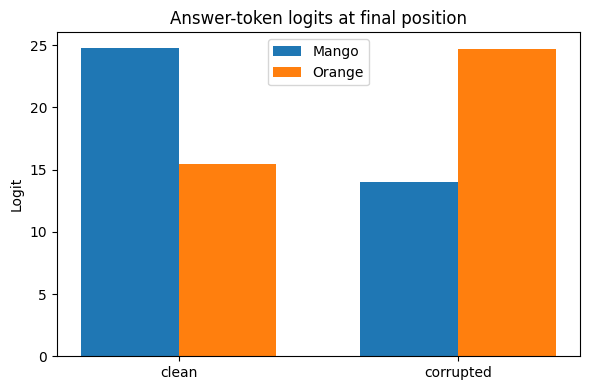

In [16]:
plot_answer_logit_comparison(stats)

### Define Metric

To quantify the model’s preference at the final token position, we use the logit difference between the clean-answer token and the corrupted-answer token:

`Difference = logit(clean_answer) - logit(corrupted_answer)`

Interpretation:
- positive difference: the model prefers the clean answer
- negative difference: the model prefers the corrupted answer
- zero difference: the model shows no preference between the two answers

This gives a single scalar summary of the behavioral contrast, which is useful for measuring recovery under activation patching.

The baseline values are:

- `baseline_clean`: logit difference on the clean prompt
- `baseline_corrupted`: logit difference on the corrupted prompt
- `baseline_clean - baseline_corrupted`: the full range of recovery available to patching

This turns the intervention into a causal recovery problem: after patching clean activations into the corrupted run, how much of the clean logit difference is restored?

How much does the model prefer Mango over Orange at the last token position?
Difference = logit(Mango) - logit(Orange)

baseline_clean is      --> 9.353167533874512
baseline_corrupted is  --> -10.723026275634766
Full Range to cover is --> 20.076193809509277


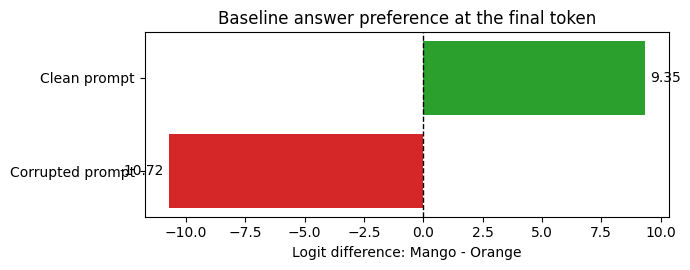

In [17]:
clean_answer_str = clean_answer.strip()
corrupted_answer_str = corrupted_answer.strip()

baseline_clean = clean_last_postion_logit[clean_token_id].item() - clean_last_postion_logit[corrupted_token_id].item()
baseline_corrupted = corrupted_last_postion_logit[clean_token_id].item() - corrupted_last_postion_logit[corrupted_token_id].item()
full_range = baseline_clean - baseline_corrupted

print(f"How much does the model prefer {clean_answer_str} over {corrupted_answer_str} at the last token position?")
print(f"Difference = logit({clean_answer_str}) - logit({corrupted_answer_str})")
print()
print(f"baseline_clean is      --> {baseline_clean}")
print(f"baseline_corrupted is  --> {baseline_corrupted}")
print(f"Full Range to cover is --> {full_range}")

plot_baseline_logit_diff(stats)

### Recovery Metric

To measure how much a patch restores clean behavior, we normalize the patched logit difference between the corrupted baseline and the clean baseline:

`recovery = (patched_diff - baseline_corrupted) / (baseline_clean - baseline_corrupted)`

`recovery = (patched_diff - baseline_corrupted) / full_range`

Interpretation:
- `0%`: patching does not improve over the corrupted run
- `100%`: patching fully restores the clean answer preference
- negative: patching makes the corrupted behavior even worse
- above `100%`: patching overshoots the clean baseline

Here, `patched_diff` is the final-token logit difference after patching:

`patched_diff = logit(clean_answer) - logit(corrupted_answer)`

This makes recovery directly comparable across layers, since each intervention is evaluated relative to the same clean and corrupted endpoints.


In [18]:
def compute_recovery(patched_diff, stats):
    return (patched_diff - stats["baseline_corrupted"]) / stats["full_range"]

### creating cache

In [19]:
_, clean_cache = model.run_with_cache(clean_prompt)
_, corrupted_cache = model.run_with_cache(corrupted_prompt)

### Layer Sweep: Patching the Residual Stream

We now patch the clean residual-stream activation from the final token position into the corrupted run, one layer at a time.

For each layer:
- take `hook_resid_post` from the clean prompt
- replace the corrupted activation at the final position
- run the model forward from that intervention
- measure the final-token logit difference and recovery score

This tests which layers contain information that is sufficient to restore the clean answer preference.

If patching a layer produces high recovery, that suggests the residual stream at that layer carries information relevant to the “remaining item” computation. If recovery stays near zero, then patching that layer does little to restore the clean behavior.


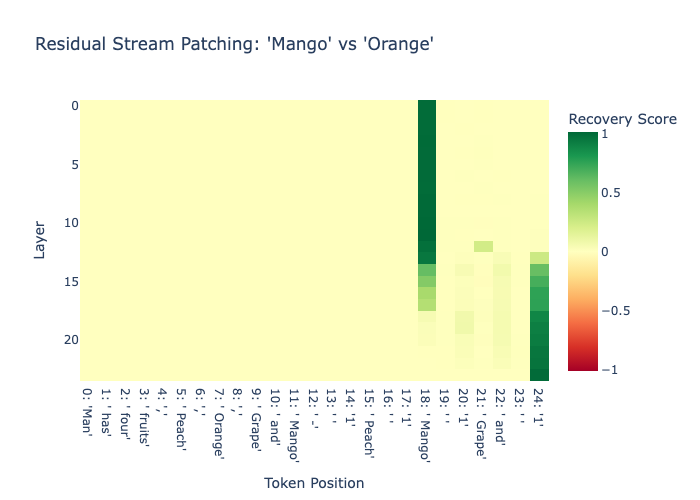

In [20]:
results_all = ResidualStreamPatchingHeatMap(model, clean_cache, corrupted_prompt, stats, position="each", plot_heatmap=True)

In [21]:
# Residual Stream Patching at the final token postion across all 24 layers
results_all = ResidualStreamPatchingByPostion(model, clean_cache, corrupted_prompt, stats, position=-1)

Layer  0 | Pos: -1 | Mango: +13.979 | Orange: +24.700 | diff: -10.721 | recovery: 0.0%
Layer  1 | Pos: -1 | Mango: +13.978 | Orange: +24.702 | diff: -10.724 | recovery: -0.0%
Layer  2 | Pos: -1 | Mango: +13.966 | Orange: +24.697 | diff: -10.730 | recovery: -0.0%
Layer  3 | Pos: -1 | Mango: +13.985 | Orange: +24.698 | diff: -10.713 | recovery: 0.0%
Layer  4 | Pos: -1 | Mango: +13.990 | Orange: +24.710 | diff: -10.720 | recovery: 0.0%
Layer  5 | Pos: -1 | Mango: +14.008 | Orange: +24.711 | diff: -10.703 | recovery: 0.1%
Layer  6 | Pos: -1 | Mango: +14.003 | Orange: +24.710 | diff: -10.707 | recovery: 0.1%
Layer  7 | Pos: -1 | Mango: +13.992 | Orange: +24.703 | diff: -10.711 | recovery: 0.1%
Layer  8 | Pos: -1 | Mango: +14.052 | Orange: +24.712 | diff: -10.660 | recovery: 0.3%
Layer  9 | Pos: -1 | Mango: +14.073 | Orange: +24.705 | diff: -10.633 | recovery: 0.5%
Layer 10 | Pos: -1 | Mango: +14.066 | Orange: +24.676 | diff: -10.609 | recovery: 0.6%
Layer 11 | Pos: -1 | Mango: +14.128 | Ora

In [22]:
# So we can see since till Pos 17 both Clean and Corrup are same .. no chages in output in corrupt even after layer sweep.. but there is something happening at postion when we swap postion 18 layer by layer .. 
results_all = ResidualStreamPatchingByPostion(model, clean_cache, corrupted_prompt, stats, position=18)

Layer  0 | Pos: 18 | Mango: +24.755 | Orange: +15.434 | diff: +9.321 | recovery: 99.8%
Layer  1 | Pos: 18 | Mango: +24.760 | Orange: +15.439 | diff: +9.322 | recovery: 99.8%
Layer  2 | Pos: 18 | Mango: +24.773 | Orange: +15.459 | diff: +9.313 | recovery: 99.8%
Layer  3 | Pos: 18 | Mango: +24.841 | Orange: +15.412 | diff: +9.429 | recovery: 100.4%
Layer  4 | Pos: 18 | Mango: +24.815 | Orange: +15.428 | diff: +9.387 | recovery: 100.2%
Layer  5 | Pos: 18 | Mango: +24.826 | Orange: +15.440 | diff: +9.386 | recovery: 100.2%
Layer  6 | Pos: 18 | Mango: +24.822 | Orange: +15.449 | diff: +9.373 | recovery: 100.1%
Layer  7 | Pos: 18 | Mango: +24.700 | Orange: +15.355 | diff: +9.345 | recovery: 100.0%
Layer  8 | Pos: 18 | Mango: +24.741 | Orange: +15.287 | diff: +9.455 | recovery: 100.5%
Layer  9 | Pos: 18 | Mango: +24.674 | Orange: +15.234 | diff: +9.440 | recovery: 100.4%
Layer 10 | Pos: 18 | Mango: +24.732 | Orange: +15.160 | diff: +9.572 | recovery: 101.1%
Layer 11 | Pos: 18 | Mango: +24.694

#### OBSERVATION
we have already found above that Layer 12 onwards we get recovery so let us go deep now in layer 

In [23]:
df_attention = patch_by_component(model, clean_cache, corrupted_prompt, stats, component="attention")
df_mlp       = patch_by_component(model, clean_cache, corrupted_prompt, stats, component="mlp")

Layer  0 | attention | recovery: 1.0%
Layer  1 | attention | recovery: 0.7%
Layer  2 | attention | recovery: 0.3%
Layer  3 | attention | recovery: 0.2%
Layer  4 | attention | recovery: 0.1%
Layer  5 | attention | recovery: 0.6%
Layer  6 | attention | recovery: -0.1%
Layer  7 | attention | recovery: -0.4%
Layer  8 | attention | recovery: 0.6%
Layer  9 | attention | recovery: 12.5%
Layer 10 | attention | recovery: 14.9%
Layer 11 | attention | recovery: 2.7%
Layer 12 | attention | recovery: 79.9%
Layer 13 | attention | recovery: 45.6%
Layer 14 | attention | recovery: 63.8%
Layer 15 | attention | recovery: -2.5%
Layer 16 | attention | recovery: 7.1%
Layer 17 | attention | recovery: 25.9%
Layer 18 | attention | recovery: 2.3%
Layer 19 | attention | recovery: 20.8%
Layer 20 | attention | recovery: 8.2%
Layer 21 | attention | recovery: 5.7%
Layer 22 | attention | recovery: 0.6%
Layer 23 | attention | recovery: 5.9%
Layer  0 | mlp | recovery: 99.5%
Layer  1 | mlp | recovery: -0.8%
Layer  2 | m

In [24]:
import pandas as pd

# Use lowercase 'layer' and 'recovery' based on the dictionary keys
df_att = df_attention.rename(columns={"recovery": "Attention_Recovery", "layer": "Layer"})
df_m = df_mlp.rename(columns={"recovery": "MLP_Recovery", "layer": "Layer"})

# Merge the two dataframes on the 'Layer' column
df_combined = pd.merge(
    df_att[['Layer', 'Attention_Recovery']], 
    df_m[['Layer', 'MLP_Recovery']], 
    on='Layer'
)

# Calculate Total Recovery
df_combined['Total_Recovery'] = df_combined['Attention_Recovery'] + df_combined['MLP_Recovery']

# Display the required columns
df_combined[['Layer', 'Attention_Recovery', 'MLP_Recovery', 'Total_Recovery']]



,Layer,Attention_Recovery,MLP_Recovery,Total_Recovery
0,0,1.0,99.5,100.5
1,1,0.7,-0.8,-0.1
2,2,0.3,-1.2,-0.9
3,3,0.2,0.5,0.7
4,4,0.1,-1.4,-1.3
5,5,0.6,-0.4,0.2
6,6,-0.1,-0.3,-0.4
7,7,-0.4,2.2,1.8
8,8,0.6,-0.7,-0.1
9,9,12.5,-3.1,9.4


#### OBSERVATION

* Above we can see till layer 11 there is no recovery, same as our earlier finding... Now layer 12 recovers 97.1% in total where 79.9% is coming from attention layer and rest 17.2% from MLP
* and then layer 13 and 14 are doing some recovery but both vio attention layers .. so lets focs on Attention layers only and now find which Attention head or heads are doing the recovery

In [25]:
df_heads = patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=12)
df_heads.recovery.sum()

Layer 12 | Head  0 | recovery: 0.3%
Layer 12 | Head  1 | recovery: 0.0%
Layer 12 | Head  2 | recovery: -0.0%
Layer 12 | Head  3 | recovery: 3.7%
Layer 12 | Head  4 | recovery: 17.2%
Layer 12 | Head  5 | recovery: -0.0%
Layer 12 | Head  6 | recovery: -0.1%
Layer 12 | Head  7 | recovery: 0.0%
Layer 12 | Head  8 | recovery: 0.0%
Layer 12 | Head  9 | recovery: 17.2%
Layer 12 | Head 10 | recovery: -0.1%
Layer 12 | Head 11 | recovery: -0.2%
Layer 12 | Head 12 | recovery: 0.0%
Layer 12 | Head 13 | recovery: -1.1%
Layer 12 | Head 14 | recovery: 0.4%
Layer 12 | Head 15 | recovery: -0.0%


37.3

In [26]:
df_heads = patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=14)
df_heads.recovery.sum()

Layer 14 | Head  0 | recovery: -0.0%
Layer 14 | Head  1 | recovery: 8.6%
Layer 14 | Head  2 | recovery: 0.1%
Layer 14 | Head  3 | recovery: -0.3%
Layer 14 | Head  4 | recovery: 0.0%
Layer 14 | Head  5 | recovery: 1.8%
Layer 14 | Head  6 | recovery: -0.0%
Layer 14 | Head  7 | recovery: 0.0%
Layer 14 | Head  8 | recovery: -0.3%
Layer 14 | Head  9 | recovery: 0.0%
Layer 14 | Head 10 | recovery: 1.2%
Layer 14 | Head 11 | recovery: 4.9%
Layer 14 | Head 12 | recovery: 0.2%
Layer 14 | Head 13 | recovery: 4.1%
Layer 14 | Head 14 | recovery: -0.4%
Layer 14 | Head 15 | recovery: 5.1%


25.0

#### OBSERVATION

Finding is Individual head recovery << layer recovery → heads are compositional, no single hero head
Here Attention layer 12 had 79.9% recovery but all attention heads for that layer just had ~40% -- This is called non-linearity of composition — heads build on each other's outputs.

What the head results actually tells:

Head 4 and Head 9 are the standouts at 17.2% each. No single head dominates — the 79.9% is a collaborative effect across multiple heads working together.


* Individual head recovery << layer recovery → heads are compositional, no single hero head -- distributed computation
* One head recovery ≈ layer recovery → that head is doing it alone, clean story

Our Case 1st.

* **Heads 4+9 individually: 17.2% each**
* **Heads 4+9 together: 74.8%  ← superadditive, not 34.4%**
* **Full layer: 79.9%**
* **Gap between sum (34.4%) and joint (74.8%) confirms compositional dependency —**
* **Head 9 sets up structural context that Head 4 requires**

In [27]:
# So lets patch few heads together and see the recovery
patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer=12, heads=[3, 4])
patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer=12, heads=[4, 9])
patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer=12, heads=[3, 4, 9])


Layer 12 | Heads [3, 4] | recovery: 16.6%
Layer 12 | Heads [4, 9] | recovery: 74.8%
Layer 12 | Heads [3, 4, 9] | recovery: 74.5%


74.46174995837572

In [28]:
df_heads = patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=12)
df_heads.recovery.sum()

Layer 12 | Head  0 | recovery: 0.3%
Layer 12 | Head  1 | recovery: 0.0%
Layer 12 | Head  2 | recovery: -0.0%
Layer 12 | Head  3 | recovery: 3.7%
Layer 12 | Head  4 | recovery: 17.2%
Layer 12 | Head  5 | recovery: -0.0%
Layer 12 | Head  6 | recovery: -0.1%
Layer 12 | Head  7 | recovery: 0.0%
Layer 12 | Head  8 | recovery: 0.0%
Layer 12 | Head  9 | recovery: 17.2%
Layer 12 | Head 10 | recovery: -0.1%
Layer 12 | Head 11 | recovery: -0.2%
Layer 12 | Head 12 | recovery: 0.0%
Layer 12 | Head 13 | recovery: -1.1%
Layer 12 | Head 14 | recovery: 0.4%
Layer 12 | Head 15 | recovery: -0.0%


37.3

In [29]:
patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer=12, heads=[4, 9])

Layer 12 | Heads [4, 9] | recovery: 74.8%


74.8210797231445

In [30]:
patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=13)

Layer 13 | Head  0 | recovery: 4.3%
Layer 13 | Head  1 | recovery: 0.1%
Layer 13 | Head  2 | recovery: 0.4%
Layer 13 | Head  3 | recovery: 0.2%
Layer 13 | Head  4 | recovery: 1.9%
Layer 13 | Head  5 | recovery: 9.3%
Layer 13 | Head  6 | recovery: -0.4%
Layer 13 | Head  7 | recovery: -0.0%
Layer 13 | Head  8 | recovery: 0.4%
Layer 13 | Head  9 | recovery: -0.4%
Layer 13 | Head 10 | recovery: 0.2%
Layer 13 | Head 11 | recovery: 0.9%
Layer 13 | Head 12 | recovery: 1.2%
Layer 13 | Head 13 | recovery: 0.0%
Layer 13 | Head 14 | recovery: 0.0%
Layer 13 | Head 15 | recovery: 0.1%


,layer,head,recovery
0,13,0,4.3
1,13,1,0.1
2,13,2,0.4
3,13,3,0.2
4,13,4,1.9
5,13,5,9.3
6,13,6,-0.4
7,13,7,-0.0
8,13,8,0.4
9,13,9,-0.4


In [31]:
patch_heads_together(model, clean_cache, corrupted_prompt, stats, layer=13, heads=[0, 5])

Layer 13 | Heads [0, 5] | recovery: 22.3%


22.335496212487378

#### OBSERVATION
* Layer 13 head sweep: Head 5 (9.3%) and Head 0 (4.3%) are the standouts.
* Combined heads 0+5 give 22.3% — far less than Layer 12's 74.8%.
* Layer 13 is a secondary contributor, not the primary circuit layer.

In [32]:
patch_by_head(model, clean_cache, corrupted_prompt, stats, layer=14)
df_heads.recovery.sum()

Layer 14 | Head  0 | recovery: -0.0%
Layer 14 | Head  1 | recovery: 8.6%
Layer 14 | Head  2 | recovery: 0.1%
Layer 14 | Head  3 | recovery: -0.3%
Layer 14 | Head  4 | recovery: 0.0%
Layer 14 | Head  5 | recovery: 1.8%
Layer 14 | Head  6 | recovery: -0.0%
Layer 14 | Head  7 | recovery: 0.0%
Layer 14 | Head  8 | recovery: -0.3%
Layer 14 | Head  9 | recovery: 0.0%
Layer 14 | Head 10 | recovery: 1.2%
Layer 14 | Head 11 | recovery: 4.9%
Layer 14 | Head 12 | recovery: 0.2%
Layer 14 | Head 13 | recovery: 4.1%
Layer 14 | Head 14 | recovery: -0.4%
Layer 14 | Head 15 | recovery: 5.1%


37.3

#### OBSERVATION
* Layer 14 head sweep: Head 1 (8.6%), Head 15 (5.1%), Head 13 (4.1%) spread across multiple heads.
* No dominant pair like Layer 12. Recovery is diffuse and weak.
* Layer 14 attention contribution (63.8% at layer level) is likely downstream effect —
* it benefits FROM Layer 12's computation rather than doing independent work.

### So far we can say LAYER 12 Is domniatiing the recovery, And in that Only Attention Layer is domanating , And in this A-L-12 only Head 4 and 9 doing almost all work

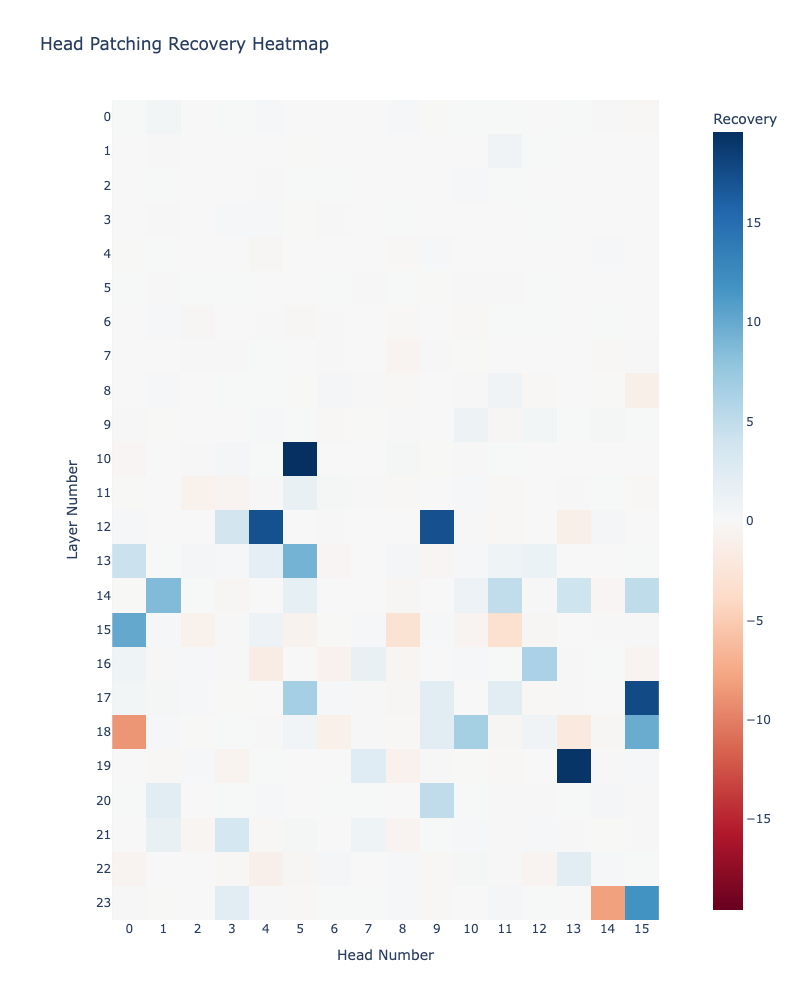

tensor([[ 9.3756e-02,  5.1549e-01,  2.7651e-02,  6.3459e-02,  1.8159e-01,
         -8.0327e-03,  5.1825e-03, -3.6957e-03,  1.7401e-01, -6.2309e-02,
          5.6880e-02,  7.2033e-02,  4.9051e-02,  7.3012e-02, -1.0947e-01,
         -1.6354e-01],
        [ 1.1876e-04, -1.1671e-01,  2.5324e-02, -1.5324e-02,  1.1638e-03,
         -4.3508e-02, -2.3599e-02,  1.6160e-02,  1.9619e-03,  7.7762e-03,
          1.9581e-02,  8.0254e-01,  7.6323e-02, -1.8992e-02,  1.7139e-02,
         -1.0617e-02],
        [ 4.2700e-02,  6.4703e-02,  2.1424e-03, -5.0353e-03, -7.5458e-02,
          9.5348e-02,  6.4442e-02,  9.0493e-03, -9.1205e-03, -2.9019e-02,
          1.5645e-01,  7.2741e-02,  3.7622e-03, -1.8308e-02,  4.3703e-03,
         -2.2222e-02],
        [ 1.7106e-02, -9.8920e-02,  4.8472e-02,  2.7402e-01,  1.8951e-01,
         -5.0514e-02, -8.2579e-02, -1.3871e-03,  6.1996e-02, -1.6113e-02,
          9.1300e-03, -1.8165e-02,  5.2942e-02,  2.5295e-02,  1.7766e-02,
         -1.6920e-02],
        [-5.9906e-02

In [33]:
patch_all_heads_heatmap(model, clean_cache, corrupted_prompt, stats)

#### OBSERVATION 
Above also we can see the same as  A-L-12 only Head 4 and 9 doing almost all work

#### Since now we have Narrowed from Residual Stream to > Attention Layer > Attention Heads -- now lets see which position in these Layer + Heads are doing the work

In [34]:
df = patch_by_head_and_position(model, clean_cache, corrupted_prompt, stats, layer=12, heads=[4, 9])
df

,position,token,recovery
0,0,Man,0.0
1,1,has,0.0
2,2,four,0.0
3,3,fruits,0.0
4,4,",",0.0
5,5,Peach,0.0
6,6,",",0.0
7,7,Orange,0.0
8,8,",",0.0
9,9,Grape,0.0


#### OBVESERVATION
This tells us that A-L-12 only Head 4 and 9 doing almost all work but even in that almost all works is done by Postion 18.. and even if look at our prompt we were swapping/corrupting our inputs at postion 18th... hence it makes sense that the postion 18th actaully tells what is missing in the set of fruits and that is coming in 18th and then gets forwarded to Postion -1 as the prediction

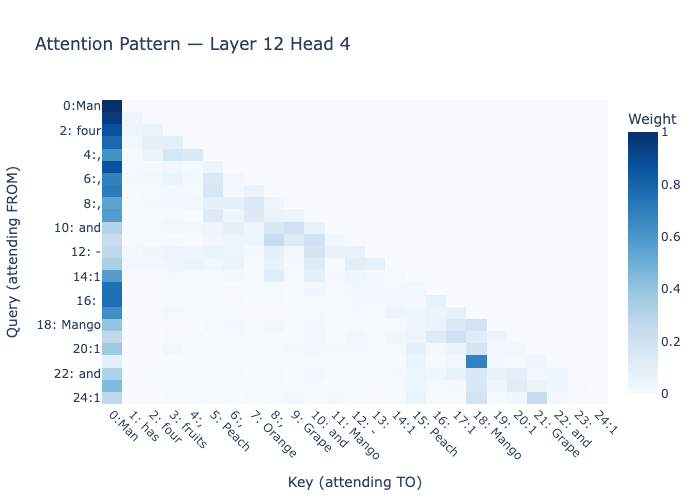

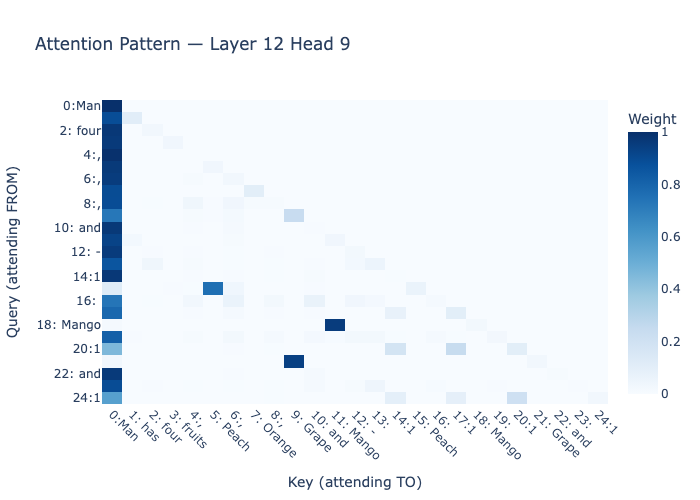

In [35]:
plot_attention_pattern(model, corrupted_prompt, layer=12, heads=[4, 9])

In [36]:
show_last_token_attention(model, corrupted_prompt, layer=12, head=4)

,token,attention_weight
0,0:Man,0.271773
21,21: Grape,0.250974
18,18: Mango,0.188017
15,15: Peach,0.059169
20,20:1,0.037434
22,22: and,0.027057
9,9: Grape,0.022851
11,11: Mango,0.021616
19,19:,0.018434
7,7: Orange,0.017254


### Observation: 
* Layer 12 Head 4 - last token (24:1) attends to Man(0.27), Grape/pos21(0.25), Mango/pos18(0.19)
* Head 4 is a list-tracking head, distributes attention across multiple counted fruit positions
* not a simple copier - doing set membership computation across the sequence

In [37]:
show_last_token_attention(model, corrupted_prompt, layer=12, head=9)

,token,attention_weight
0,0:Man,0.561958
20,20:1,0.209080
14,14:1,0.094339
17,17:1,0.090385
24,24:1,0.027696
8,"8:,",0.003602
10,10: and,0.002393
6,"6:,",0.002048
19,19:,0.001704
12,12: -,0.001486


### Observation: 
* Layer 12 Head 9 — is a counting structure head — attends to Man(0.56) and digits 1(0.39)
* Fruit tokens get near-zero weight — Head 9 is a counting structure head, completely ignores fruit identity
* Its recovery contribution is indirect — sets up structural context that Head 4 relies on

## ABLATION

In [38]:
ablate_heads(model, clean_prompt, stats, layer=12, heads=[4,9])

Baseline clean logit diff :  +9.353
After ablating L12 H[4, 9]: +8.944
Damage: +0.410


8.943583488464355

### Observation
Ablation: Heads 4 and 9 on the Clean Run

We zero out the output of Heads 4 and 9 at Layer 12 on the clean prompt.
Damage: 0.41 out of 9.35 baseline — roughly 4.4%.

The model barely notices they are gone.

This seems to contradict the patching result, where these same heads delivered
substantial recovery. The reconciliation is that patching and ablation ask
different questions:

- Patching asks: can this component carry the clean signal into a corrupted run?
- Ablation asks: is this component necessary when the clean run is intact?

On the clean run, multiple heads across Layer 12 (and possibly other layers)
are redundantly computing the same set-completion information. When Heads 4
and 9 are removed, the other heads compensate and the answer is preserved.

Conclusion: Heads 4 and 9 are sufficient to carry the signal, but not
necessary. The computation is distributed across the layer, not localized
to two heads.

### Ablation: All Attention Heads at Layer 12 on the Clean Run

In [39]:
ablate_full_layer_attention(model, clean_prompt, stats, layer=12)

Baseline clean logit diff:       +9.353
After zeroing all L12 attn: +8.657
Damage:                          +0.697


8.656665802001953

#### Obseervation of above Results


We zero out the entire attention layer at Layer 12 — all 16 heads simultaneously.
Damage: 0.697 out of 9.353 baseline — roughly 7.4%.

Even destroying the entire attention layer barely moves the answer.

This extends the previous finding: the redundancy is not just within Heads 4
and 9 — it exists across the entire layer. Removing all 16 heads still leaves
the model capable of producing the correct answer at 92.6% of baseline strength.

The clean run has multiple independent paths to the correct answer. Layer 12
attention is one of them, but the others — likely other layers and MLP blocks
— are sufficient on their own.

This sets up the critical question: does Layer 12 attention matter at all?
The next experiment answers that by running the same ablation on the corrupted
prompt instead of the clean one.

### CRITICAL EXPERIMENT: Same ablation, corrupted run instead of clean
* Clean run damage was 7.4% — model barely noticed
* Corrupted run damage: 99.1% — total collapse
* This asymmetry is the main finding: Layer 12 attention is redundant on clean,
* causally necessary on corrupted. Every other path is already carrying the wrong answer.

In [40]:
ablate_full_layer_attention(model, corrupted_prompt, stats, layer=12)

Baseline clean logit diff:       +9.353
After zeroing all L12 attn: +0.080
Damage:                          +9.273


0.08028793334960938

In [41]:
# Ablation summary — clean run vs corrupted run comparison
print(f"{'Intervention':<35} {'Run':<12} {'Damage':>8} {'% baseline':>12}")
print("-" * 70)
print(f"{'Ablate Heads 4+9':<35} {'Clean':<12} {'0.41':>8} {'4.4%':>12}")
print(f"{'Ablate full L12 attention':<35} {'Clean':<12} {'0.70':>8} {'7.4%':>12}")
print(f"{'Ablate full L12 attention':<35} {'Corrupted':<12} {'9.27':>8} {'99.1%':>12}")

Intervention                        Run            Damage   % baseline
----------------------------------------------------------------------
Ablate Heads 4+9                    Clean            0.41         4.4%
Ablate full L12 attention           Clean            0.70         7.4%
Ablate full L12 attention           Corrupted        9.27        99.1%


In [42]:

inspect_qk(model, layer=12, head=4)
inspect_qk(model, layer=12, head=9)

Layer 12 Head 4 — QK matrix shape: torch.Size([2048, 2048])
Top 5 singular values: [1.419628381729126, 1.332153558731079, 1.267047643661499, 1.251627802848816, 1.2146029472351074]

Direction 1 (singular value: 1.42)
  Query side (looking for): [' breakdown', 'GV', ' po', '打法', ' gown', ' sparks', '。\n\n', '。”\n\n', '”。\n\n', '往返']
  Key side   (offering):    [' Lawyer', 'Last', ' rendition', 'inning', ' отнош', ' способ', ' Proud', '嗎', '($"', ' pus']

Direction 2 (singular value: 1.33)
  Query side (looking for): [' Offering', 'RESSED', ' readers', '粮食', ' mon', ' Drink', 'pet', 'Mon', '驴', ' english']
  Key side   (offering):    ['ButtonText', 'rocess', '董事长', 'Rew', 'story', 'tw', ' sich', 'Deque', '台南', 'зв']

Direction 3 (singular value: 1.27)
  Query side (looking for): ['○', ' currency', ' Adrian', ' Currency', '离退休', ' Peggy', '常委会', 'baum', 'hor', ' Beverage']
  Key side   (offering):    [' Lane', ".',", ' Led', ' crowdfunding', 'Panel', ' Canvas', ' canvas', ' execution', ' B

In [43]:
inspect_vout(model, layer=12, head=4)
inspect_vout(model, layer=12, head=9)

Layer 12 Head 4 — W_V @ W_O
Top 5 singular values: [1.5245919227600098, 1.1634242534637451, 1.0494790077209473, 0.9957133531570435, 0.9790405035018921]

Direction 1 (sv=1.52)
  Top tokens written to output: [' IC', ' pepp', ' json', 'aley', ' peppers', '的新', ' Feather', ' Ecuador', 'Apple', ' google', ' feather', ' Fal', ' Jesse', '(%', ' Ble']
  Fruit token ranks: {'Mango': 2623, 'Orange': 20905, 'Peach': 82, 'Grape': 37106}

Direction 2 (sv=1.16)
  Top tokens written to output: [' upcoming', ' му', ' excit', 'ague', 'án', 'HB', ' glyphicon', 'hop', '_exec', 'chn', '啸', ' Ending', '死角', ' hogy', ' fils']
  Fruit token ranks: {'Mango': 27966, 'Orange': 12668, 'Peach': 82653, 'Grape': 141526}

Direction 3 (sv=1.05)
  Top tokens written to output: [' leftover', '每日', 'Ident', 'mkdir', ' ox', 'UserId', ' disk', 'Predict', ' coordinated', ' reflux', '/in', 'oved', '-Encoding', 'recognized', ' piss']
  Fruit token ranks: {'Mango': 125604, 'Orange': 55743, 'Peach': 27846, 'Grape': 133340}

L

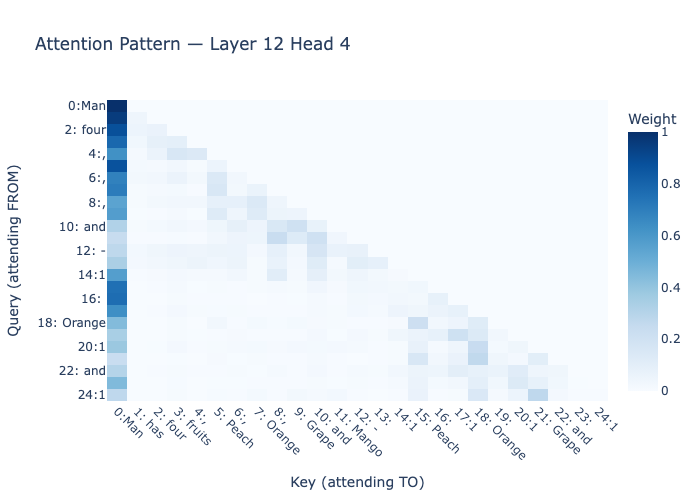

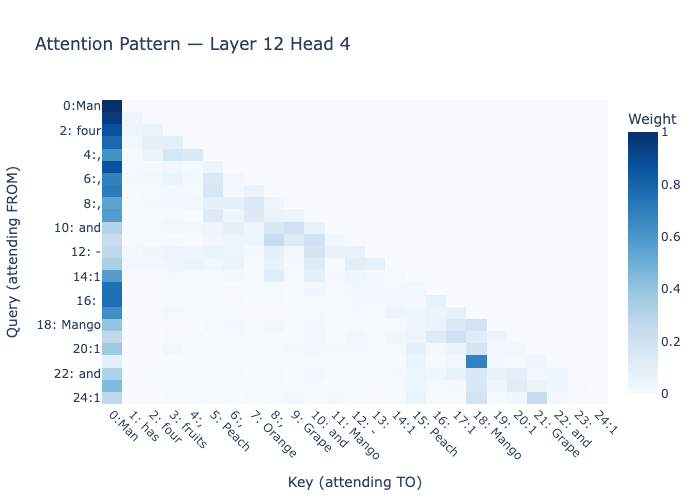

In [44]:
# compare Head 4 attention patterns side by side
plot_attention_pattern(model, clean_prompt, layer=12, heads=[4])
plot_attention_pattern(model, corrupted_prompt, layer=12, heads=[4])

In [45]:
def head_direct_logit_attribution(model, prompt, layer, head, read_pos=-1):
    """
    Project Head's output contribution directly through the unembedding matrix.
    This tells you what tokens the head is pushing the model toward predicting.
    
    W_U maps from d_model → vocab. This is the right lens for output-side analysis.
    """
    _, cache = model.run_with_cache(prompt)
    
    # Head output: z has shape (batch, seq, n_heads, d_head)
    z = cache[f"blocks.{layer}.attn.hook_z"]   # (1, seq, n_heads, d_head)
    
    # W_O for this head: (d_head, d_model)
    W_O = model.W_O[layer, head]               # (d_head, d_model)
    
    # Head's contribution to residual stream at read_pos
    head_out = z[0, read_pos, head, :] @ W_O   # (d_model,)
    
    # Project through unembedding (W_U: d_model → vocab)
    # TransformerLens stores W_U as (d_model, vocab)
    W_U = model.W_U                             # (d_model, vocab)
    logit_contribution = head_out @ W_U         # (vocab,)
    
    # Top promoted and suppressed tokens
    top_promoted  = logit_contribution.topk(15)
    top_suppressed = (-logit_contribution).topk(15)
    
    promoted_tokens   = [model.to_string(i) for i in top_promoted.indices]
    suppressed_tokens = [model.to_string(i) for i in top_suppressed.indices]
    
    print(f"Layer {layer} Head {head} — Direct Logit Attribution (pos {read_pos})")
    print(f"  Tokens PROMOTED  (head pushes model toward): {promoted_tokens}")
    print(f"  Tokens SUPPRESSED (head pushes model away from): {suppressed_tokens}")
    
    # Check fruit token positions specifically
    fruit_tokens = [" Mango", " Orange", " Peach", " Grape"]
    fruit_ids = [model.to_single_token(t) for t in fruit_tokens]
    print(f"\n  Fruit-specific contributions:")
    for fname, fid in zip(fruit_tokens, fruit_ids):
        val = logit_contribution[fid].item()
        print(f"    {fname.strip():8s}: {val:+.4f}")
    
    return logit_contribution

# Run on both clean and corrupted prompts for comparison
print("=== CLEAN PROMPT ===")
contrib_clean_h4 = head_direct_logit_attribution(model, clean_prompt, layer=12, head=4)

print("\n=== CORRUPTED PROMPT ===")
contrib_corrupt_h4 = head_direct_logit_attribution(model, corrupted_prompt, layer=12, head=4)

print("\n=== HEAD 9 (corrupted, for comparison) ===")
contrib_corrupt_h9 = head_direct_logit_attribution(model, corrupted_prompt, layer=12, head=9)

=== CLEAN PROMPT ===
Layer 12 Head 4 — Direct Logit Attribution (pos -1)
  Tokens PROMOTED  (head pushes model toward): ['斫', '意见反馈', '≦', '｀', ' elkaar', '爱奇', '埝', '唑', '塱', 'że', 'declspec', '"default', '对他们', ' htonl', '做大']
  Tokens SUPPRESSED (head pushes model away from): ['5', '不可', '诀', '2', '!', '�', '8', '信用', 'http', '7', '学习', '分配', '.', '4', '鸨']

  Fruit-specific contributions:
    Mango   : +0.0867
    Orange  : -0.0673
    Peach   : +0.0627
    Grape   : -0.1674

=== CORRUPTED PROMPT ===
Layer 12 Head 4 — Direct Logit Attribution (pos -1)
  Tokens PROMOTED  (head pushes model toward): ['各自的', ' buttonText', '爱奇', '对他们', '意见反馈', 'それぞれ', ' vô', '各自', '踽', ' elkaar', '"><?=$', '钢管', 'ession', '意外', '传奇游戏']
  Tokens SUPPRESSED (head pushes model away from): ['�', '竭', '分配', '.annotations', '信用', 'EMAIL', ' unf', '判', '彻底', '不仅是', '考', '学会', '努力', '交换', '不懈']

  Fruit-specific contributions:
    Mango   : +0.0615
    Orange  : +0.1413
    Peach   : +0.1168
    Grape   : +0.

### DLA

In [46]:
df_layer = compute_layer_dla(model, clean_cache, stats)
df_layer

,layer,dla_score
0,0,0.1349
1,1,0.1312
2,2,0.3580
3,3,0.1410
4,4,-0.0261
5,5,0.2943
6,6,0.0066
7,7,-0.1517
8,8,-0.4789
9,9,-0.5033


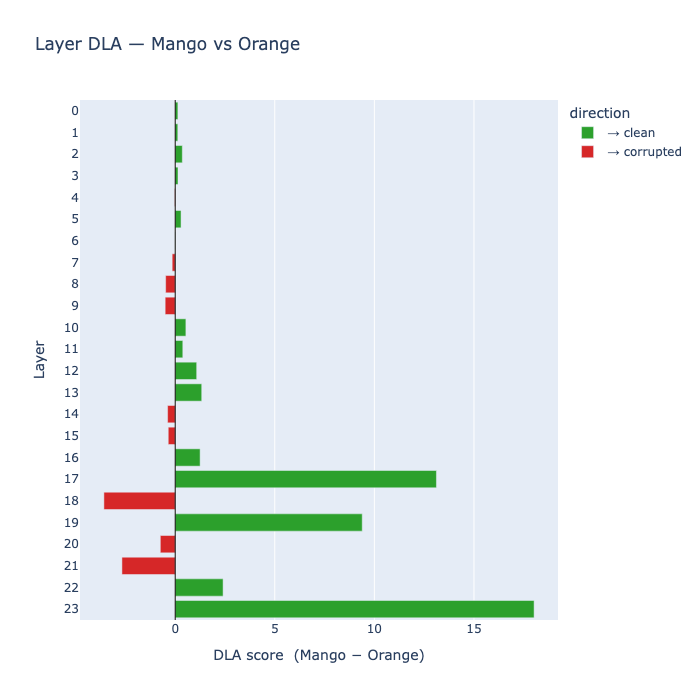

In [47]:
plot_layer_dla(df_layer, stats)

In [48]:
df_layer_corrupt = compute_layer_dla(model, corrupted_cache, stats)
df_layer_corrupt

,layer,dla_score
0,0,0.1333
1,1,0.1275
2,2,0.3412
3,3,0.1528
4,4,-0.0017
5,5,0.3675
6,6,0.0005
7,7,-0.1027
8,8,-0.6501
9,9,-0.2578


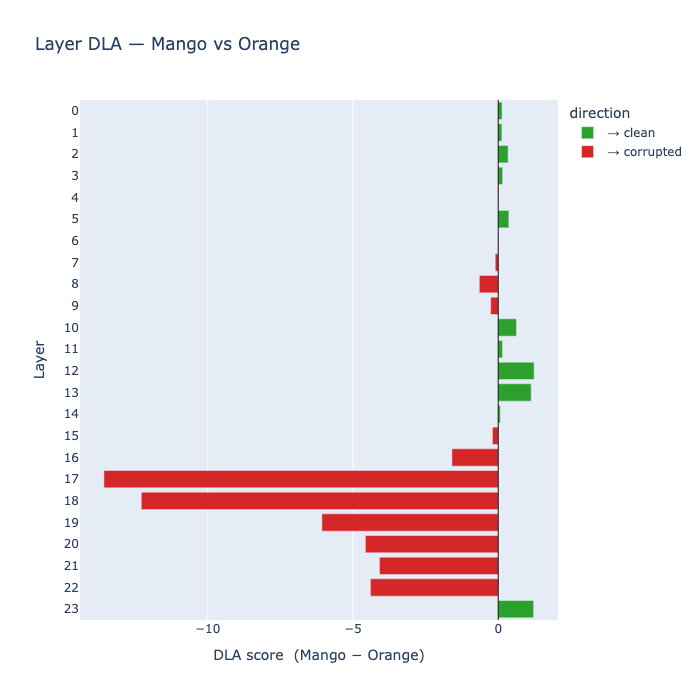

In [49]:
plot_layer_dla(df_layer_corrupt, stats)

### OBSERVATION OF LAYER DLA
* Layer DLA shows where the model directly votes for the answer token - not where it computes.
* Layers 17, 19, 23 dominate: +9.17, +7.46, +18.84. These are the output writers.
* Layer 12 scores only +1.05 here — consistent with patching: it builds the representation, not the vote.
* Layers 20 and 21 are actively negative (-2.48, -1.05) — suppressing the correct answer even on the clean run, overridden by the large positive layers.
* DLA and patching are measuring different things: patching finds where the computation happens, DLA finds where it gets converted into token space.

In [50]:
# # Step 2 — within the dominant layer, which heads
df_l17 = compute_head_dla(model, clean_cache, stats, layer=17)
df_l19 = compute_head_dla(model, clean_cache, stats, layer=19)
df_l23 = compute_head_dla(model, clean_cache, stats, layer=23)

df_l17,df_l19,df_l23

(    head  dla_score
 0      0    -0.0500
 1      1     0.2181
 2      2    -0.0526
 3      3     0.0308
 4      4     0.0023
 5      5     6.5746
 6      6     0.0556
 7      7    -0.0847
 8      8    -0.2835
 9      9     1.1156
 10    10    -0.0451
 11    11    -0.3708
 12    12     0.0330
 13    13    -0.1802
 14    14    -0.0392
 15    15     5.7098,
     head  dla_score
 0      0    -0.0163
 1      1     0.2279
 2      2    -0.2681
 3      3    -0.1782
 4      4    -0.1830
 5      5     0.0045
 6      6    -0.0639
 7      7     0.5537
 8      8    -0.0539
 9      9    -0.0829
 10    10    -0.1392
 11    11     0.2737
 12    12    -0.0642
 13    13    10.6863
 14    14    -0.2130
 15    15    -0.5378,
     head  dla_score
 0      0    -0.2320
 1      1    -0.1614
 2      2    -0.0176
 3      3     1.1382
 4      4    -0.3782
 5      5    -0.0797
 6      6     0.3412
 7      7     0.0863
 8      8    -0.1418
 9      9    -0.6942
 10    10     0.2957
 11    11     0.1899
 12    12  

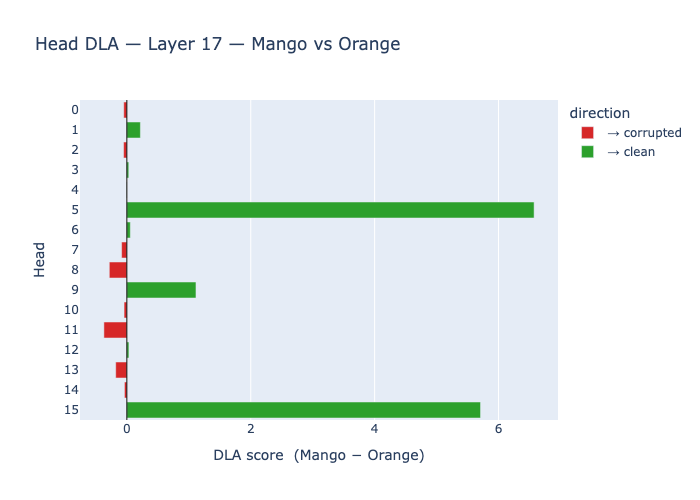

In [51]:
plot_head_dla(df_l17, layer=17, stats=stats)

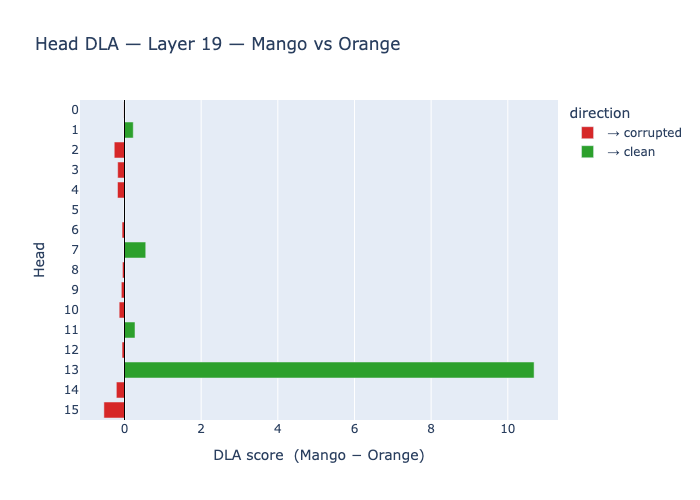

In [52]:
plot_head_dla(df_l19, layer=19, stats=stats)

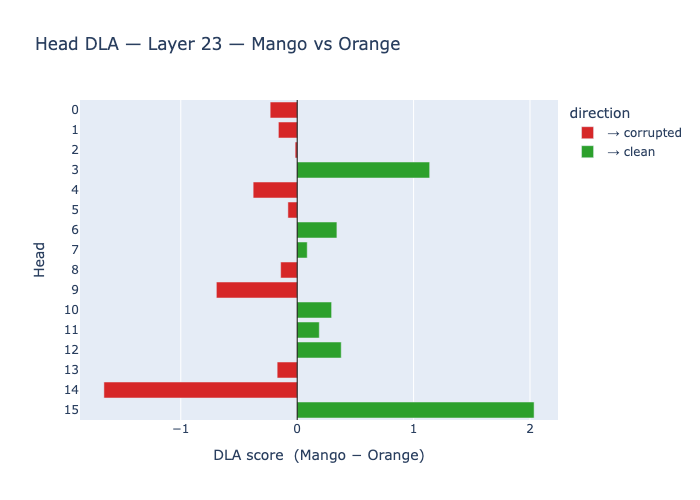

In [53]:
plot_head_dla(df_l23, layer=23, stats=stats)

### OBSERVATION
* Layer DLA — clean vs corrupted runs reveal a two-stage circuit.
* Layers 0-13 are nearly identical across both runs — early computation is prompt-invariant.
* Layer 16 is the first sign flip: clean +1.25, corrupted -1.59. The model starts committing here.
* Layer 17 is the decisive split: clean +13.12 (H5: +6.57, H15: +5.71), corrupted -13.58.
* L19 H13 (+10.69) and L23 H15 (+2.03) are the other major output writers on the clean run.
* On corrupted, layers 17-22 cascade uniformly negative — no oscillation, just commitment to the wrong answer.

In [54]:
# # Step 3 — what is a specific head actually saying
df_tokens = compute_single_head_dla(model, clean_cache, layer=17, head=5)
df_tokens

,token,logit
0,' mango',8.5686
1,' Mango',7.2619
2,'芒果',6.5850
3,'王某',6.1041
4,' Manning',5.6539
5,'莫斯',5.5549
6,'馍',5.4588
7,' Glover',5.1658
8,' mang',5.1583
9,'GM',5.1578


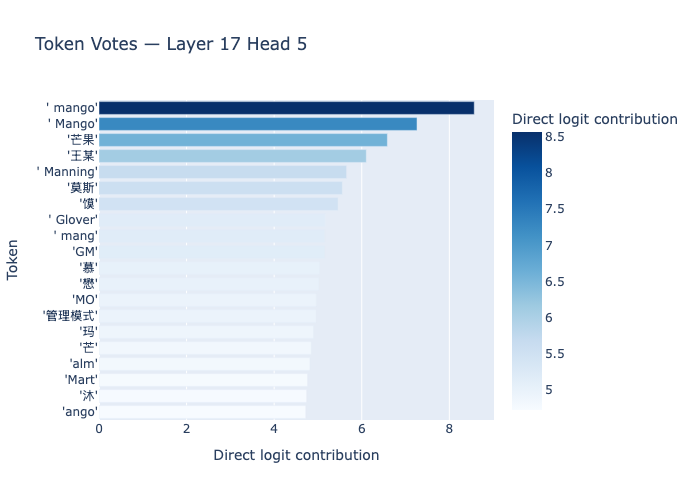

In [55]:
plot_single_head_dla(df_tokens, layer=17, head=5)

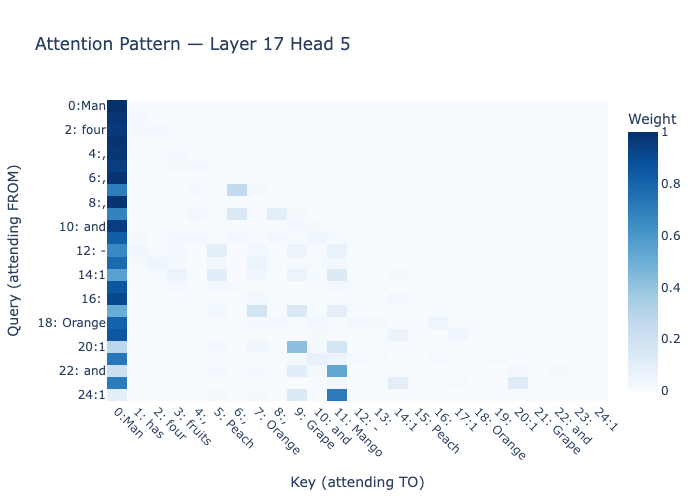

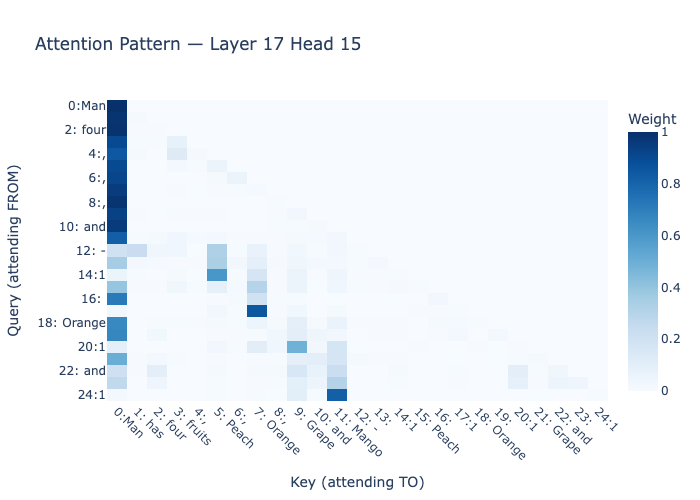

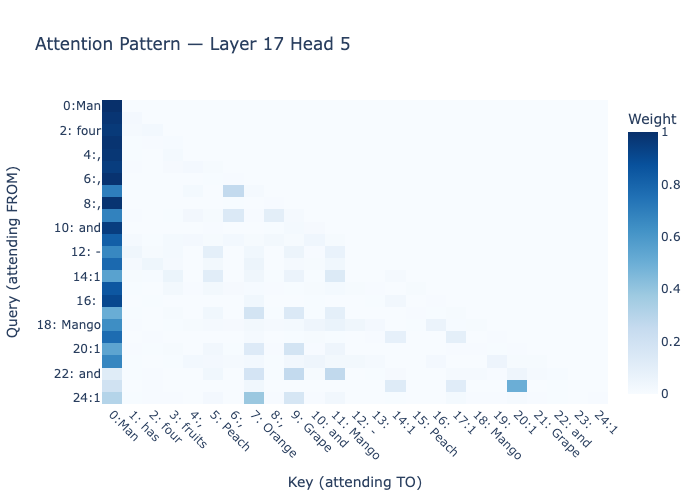

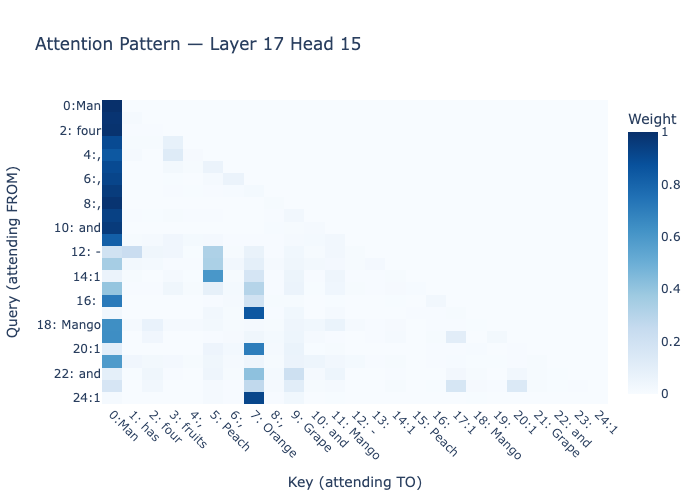

In [56]:
# compare Head 5,15 attention patterns side by side
plot_attention_pattern(model, clean_prompt, layer=17, heads=[5, 15])
plot_attention_pattern(model, corrupted_prompt, layer=17, heads=[5, 15])

### OVESERVATION

* Clean run: both heads attend to position 11 (Mango) in the declaration section.
* Corrupted run: both heads shift to position 7 (Orange) in the declaration section.
* The declaration is identical in both prompts — the shift is driven by which fruit is absent from the counted list.
* These heads are not computing — they are copying: attend to the missing fruit in the declaration, write it to output.
* **This closes the circuit: L12 H4+H9 compute what is missing, L17 H5+H15 find it in the declaration and copy it.**
*